# Módulo 4 — Fine-tuning eficiente con LoRA

**Objetivo:** ajustar un Transformer preentrenado a la clasificación de AG News
mediante adaptadores LoRA, y compararlo contra el baseline TF-IDF del Módulo 3
sobre el mismo test set.

**Modelo base: `distilbert-base-uncased`.** La elección responde a los dos criterios
de la consigna: (a) *idioma* — el corpus está en inglés y DistilBERT está preentrenado
en inglés; (b) *cómputo* — con ~67M de parámetros entrena en minutos en la GPU
gratuita de Colab, mientras que un `bert-base` duplica el costo sin garantía de mejora
en un corpus de documentos cortos.

> **Este notebook se ejecuta en Google Colab con GPU** (Entorno de ejecución →
> Cambiar tipo de entorno → GPU T4). Todo lo demás es automático.

In [10]:
# Dependencias (Colab ya trae torch; peft no viene preinstalado)
!pip install -q "transformers>=4.41" "datasets>=2.19" "peft>=0.10" "accelerate>=0.30"

## 1. Evidencia de entorno GPU

In [11]:
import torch, time, json, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("GPU disponible:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
assert torch.cuda.is_available(), "Activar GPU: Entorno de ejecución -> Cambiar tipo de entorno"

GPU disponible: True
GPU: Tesla T4


## 2. Datos: el mismo corpus y los mismos splits de todo el proyecto

Se clona el repositorio del proyecto (los CSVs de la cátedra están versionados) y se
reproduce el split de validación del Módulo 3: 10% del train, estratificado, semilla 42.
El test set queda reservado para **una única evaluación final**.

In [12]:
# SMOKE = True corre una prueba rápida (1.500 docs, 1 época) para validar el entorno.
# Para la corrida real, poner SMOKE = False y ejecutar todo de nuevo.
SMOKE = False

In [13]:
import os
import pandas as pd

if not os.path.exists("nlp-capstone-agnews"):
    !git clone -q https://github.com/frncsco33/nlp-capstone-agnews.git
REPO = "nlp-capstone-agnews"

LABEL_NAMES = ["World", "Sports", "Business", "Sci_Tech"]
LABEL2ID = {name: i for i, name in enumerate(LABEL_NAMES)}

train_full = pd.read_csv(f"{REPO}/data/ag_news/ag_news_train.csv")
test = pd.read_csv(f"{REPO}/data/ag_news/ag_news_test.csv")
for df in (train_full, test):
    df["labels"] = df["label"].map(LABEL2ID)

from sklearn.model_selection import train_test_split
tr, val = train_test_split(train_full, test_size=0.1, random_state=SEED,
                           stratify=train_full["labels"])

if SMOKE:
    tr = tr.sample(1500, random_state=SEED)
    val = val.sample(300, random_state=SEED)

print(f"train: {len(tr):,} | val: {len(val):,} | test: {len(test):,} | SMOKE={SMOKE}")

train: 7,200 | val: 800 | test: 2,000 | SMOKE=False


## 3. Tokenización y `max_len` medido con el tokenizador del modelo

El percentil 95 de longitud del Módulo 2 se calculó sobre el texto limpio
(lematizado, sin stop-words). El Transformer consume el **texto crudo** en
**subword tokens** — otra moneda: las stop-words vuelven y las palabras se parten.
Por eso el `max_len` se recalcula aquí con el propio tokenizador de DistilBERT;
usar el p95 del Módulo 2 truncaría bastante más del 5% de los documentos.

In [14]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

subword_lens = [len(ids) for ids in tokenizer(train_full["text"].tolist(),
                                              truncation=False)["input_ids"]]
MAX_LEN = int(np.percentile(subword_lens, 95))
print(f"p95 de subword tokens (texto crudo): {MAX_LEN}")
print(f"(compárese con el p95 del texto limpio del Módulo 2)")

p95 de subword tokens (texto crudo): 83
(compárese con el p95 del texto limpio del Módulo 2)


In [15]:
from datasets import Dataset

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

cols = ["text", "labels"]
ds_train = Dataset.from_pandas(tr[cols], preserve_index=False).map(tokenize, batched=True)
ds_val = Dataset.from_pandas(val[cols], preserve_index=False).map(tokenize, batched=True)
ds_test = Dataset.from_pandas(test[cols], preserve_index=False).map(tokenize, batched=True)

Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## 4. Configuración LoRA

- **`r = 8`**: la tarea es clasificación de tópicos con 4 clases y alta separabilidad
  léxica; no requiere adaptadores de gran capacidad. Con `r = 8` cada adaptador añade
  dos matrices de rango bajo (768×8) por proyección.
- **`lora_alpha = 16`**: escala efectiva `alpha/r = 2`, valor conservador que evita
  que los adaptadores dominen sobre los pesos preentrenados congelados.
- **Módulos objetivo `q_lin` y `v_lin`**: las proyecciones de *query* y *value* de la
  atención de DistilBERT — donde Hu et al. (2021) reportan el mejor ratio
  rendimiento/parámetros. (En BERT/RoBERTa los módulos se llaman `query`/`value`.)

In [16]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='You are sending unauthenticated requests to the HF Hub')

!pip install --upgrade torchao

from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABEL_NAMES),
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id=LABEL2ID,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


## 5. Análisis de parámetros: totales vs. entrenables

El porcentaje entrenable incluye los adaptadores LoRA **y** la cabeza de
clasificación (`pre_classifier` + `classifier`), que PEFT marca entrenable con
`TaskType.SEQ_CLS` porque se inicializa desde cero para las 4 clases.

In [17]:
total = sum(p.numel() for p in model.parameters())
entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
lora_params = sum(p.numel() for n, p in model.named_parameters()
                  if p.requires_grad and "lora" in n)
head_params = entrenables - lora_params
pct = 100 * entrenables / total
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {entrenables:,}  ({pct:.2f}%)")
print(f"  - adaptadores LoRA:    {lora_params:,}")
print(f"  - cabeza de clasific.: {head_params:,}")
assert pct < 3, "El criterio del módulo exige < 3% de parámetros entrenables"

Parámetros totales:      67,697,672
Parámetros entrenables:  741,124  (1.09%)
  - adaptadores LoRA:    147,456
  - cabeza de clasific.: 593,668


## 6. Entrenamiento

La validación por época corre sobre el **split de validación**, no sobre el test:
el test se evalúa una sola vez al final, igual que en el Módulo 3.

In [18]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted",
                                                  zero_division=0)
    _, _, f1_m, _ = precision_recall_fscore_support(labels, preds, average="macro",
                                                    zero_division=0)
    return {"accuracy": accuracy_score(labels, preds),
            "precision": p, "recall": r, "f1_weighted": f1, "f1_macro": f1_m}

args = TrainingArguments(
    output_dir="outputs/lora",
    learning_rate=2e-4,            # LoRA tolera lr más alto que el full fine-tuning
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=1 if SMOKE else 3,
    eval_strategy="epoch",         # en transformers < 4.41: evaluation_strategy
    save_strategy="no",
    logging_strategy="epoch",
    fp16=True,
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer.train()
tiempo_entrenamiento = time.time() - t0
print(f"Tiempo de entrenamiento: {tiempo_entrenamiento/60:.1f} min")

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Weighted,F1 Macro
1,0.428128,0.256763,0.922500,0.923895,0.922500,0.922542,0.922542
2,0.278048,0.241525,0.920000,0.920692,0.920000,0.919640,0.919640
3,0.252457,0.237315,0.923750,0.924486,0.923750,0.923546,0.923546


Tiempo de entrenamiento: 1.2 min


## 7. Estadísticas de entrenamiento (loss train vs. validación)

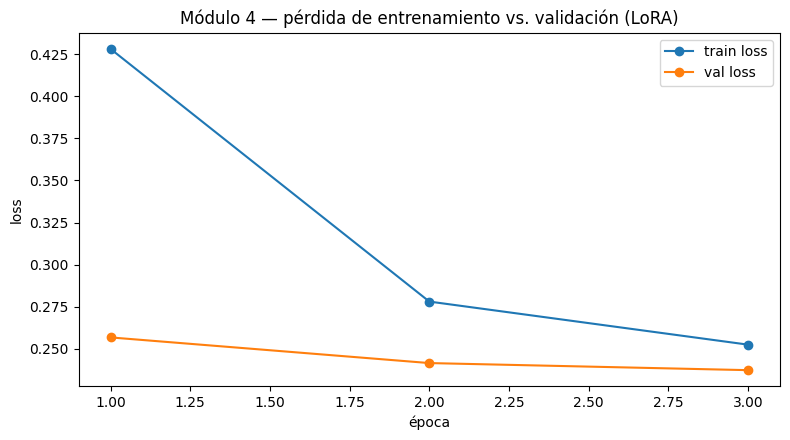

In [19]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train_loss = [(e["epoch"], e["loss"]) for e in log if "loss" in e]
val_loss = [(e["epoch"], e["eval_loss"]) for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(*zip(*train_loss), marker="o", label="train loss")
ax.plot(*zip(*val_loss), marker="o", label="val loss")
ax.set_xlabel("época")
ax.set_ylabel("loss")
ax.set_title("Módulo 4 — pérdida de entrenamiento vs. validación (LoRA)")
ax.legend()
fig.tight_layout()
fig.savefig("m4_loss_curve.png", dpi=150)
plt.show()

## 8. Evaluación única sobre el test set

              precision    recall  f1-score   support

       World     0.9465    0.8840    0.9142       500
      Sports     0.9664    0.9780    0.9722       500
    Business     0.8451    0.8620    0.8535       500
    Sci_Tech     0.8859    0.9160    0.9007       500

    accuracy                         0.9100      2000
   macro avg     0.9110    0.9100    0.9101      2000
weighted avg     0.9110    0.9100    0.9101      2000



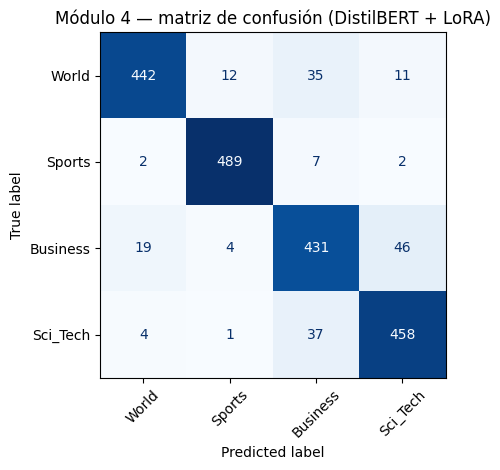

In [20]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

pred_out = trainer.predict(ds_test)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = test["labels"].to_numpy()

print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                              display_labels=LABEL_NAMES)
disp.plot(xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Módulo 4 — matriz de confusión (DistilBERT + LoRA)")
plt.tight_layout()
plt.savefig("m4_confusion.png", dpi=150)
plt.show()

## 9. Tabla comparativa: baseline TF-IDF (M3) vs. DistilBERT + LoRA (M4)

Ambas columnas se evaluaron sobre el mismo `ag_news_test.csv` (2.000 documentos).

In [21]:
rep = classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True)

with open(f"{REPO}/reports/metrics/baseline_tfidf.json") as f:
    baseline = json.load(f)
rep_a = baseline["classification_report"]

def fila(metrica, a, b, fmt="{:.4f}"):
    delta = b - a
    return [metrica, fmt.format(a), fmt.format(b), f"{delta:+.4f}"]

filas = [
    fila("Accuracy", rep_a["accuracy"], rep["accuracy"]),
    fila("Precision (weighted)", rep_a["weighted avg"]["precision"],
         rep["weighted avg"]["precision"]),
    fila("Recall (weighted)", rep_a["weighted avg"]["recall"],
         rep["weighted avg"]["recall"]),
    fila("F1 (weighted)", rep_a["weighted avg"]["f1-score"],
         rep["weighted avg"]["f1-score"]),
    fila("F1 (macro)", rep_a["macro avg"]["f1-score"], rep["macro avg"]["f1-score"]),
]
comparativa = pd.DataFrame(
    filas, columns=["Métrica", "A · TF-IDF + LogReg", "B · DistilBERT + LoRA", "Δ"]
)
comparativa.loc[len(comparativa)] = [
    "Parámetros entrenables", f"{baseline['parametros_entrenables']:,}",
    f"{entrenables:,}", "—"]
comparativa.loc[len(comparativa)] = [
    "Tiempo de entrenamiento", f"{baseline['tiempo_entrenamiento_seg']:.0f} s",
    f"{tiempo_entrenamiento:.0f} s", "—"]
comparativa

,Métrica,A · TF-IDF + LogReg,B · DistilBERT + LoRA,Δ
0,Accuracy,0.8960,0.9100,+0.0140
1,Precision (weighted),0.8961,0.9110,+0.0148
2,Recall (weighted),0.8960,0.9100,+0.0140
3,F1 (weighted),0.8960,0.9101,+0.0141
4,F1 (macro),0.8960,0.9101,+0.0141
5,Parámetros entrenables,"36,864","741,124",—
6,Tiempo de entrenamiento,0 s,75 s,—


> **Nota sobre la columna A:** esta tabla se generó en la ejecución de Colab leyendo `reports/metrics/baseline_tfidf.json` del repositorio *tal como estaba al momento de la corrida*. El Módulo 3 se re-ejecutó después (mejora de la limpieza de entidades HTML detectada por el EDA), así que la columna A definitiva — con diferencias de décimas — es la del JSON actual del repositorio y la del informe PDF. La columna B (LoRA) es la de esta corrida y no cambia.

## 10. Exportar resultados

In [22]:
resultados = {
    "classification_report": rep,
    "modelo": MODEL_NAME,
    "lora": {"r": 8, "lora_alpha": 16, "lora_dropout": 0.1,
             "target_modules": ["q_lin", "v_lin"]},
    "max_len_p95_subword": MAX_LEN,
    "parametros": {"totales": total, "entrenables": entrenables,
                   "lora": lora_params, "cabeza": head_params,
                   "porcentaje_entrenable": round(pct, 2)},
    "tiempo_entrenamiento_seg": round(tiempo_entrenamiento, 1),
    "epocas": args.num_train_epochs,
    "gpu": torch.cuda.get_device_name(0),
    "smoke": SMOKE,
    "log_history": log,
    "versiones": {},
}
import transformers, peft, datasets as ds_lib
resultados["versiones"] = {"torch": torch.__version__,
                           "transformers": transformers.__version__,
                           "peft": peft.__version__,
                           "datasets": ds_lib.__version__}

with open("lora_transformer.json", "w") as f:
    json.dump(resultados, f, indent=2)

!zip -q resultados_m4.zip lora_transformer.json m4_confusion.png m4_loss_curve.png
from google.colab import files; files.download("resultados_m4.zip")
print("Listo: descargar resultados_m4.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Listo: descargar resultados_m4.zip
